## Importing ibraries

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Dense
from keras.utils import  normalize
from random import randint, choice

## Loading data form MNIST dataset
This dataset contains images of numbers from 0 to 9 represented as 28 by 28 matrices

In [2]:
(train_X, train_y), (test_X, test_y) = mnist.load_data()

print('X_train: ' + str(train_X.shape))
print('Y_train: ' + str(train_y.shape))
print('X_test:  '  + str(test_X.shape))
print('Y_test:  '  + str(test_y.shape))

X_train: (60000, 28, 28)
Y_train: (60000,)
X_test:  (10000, 28, 28)
Y_test:  (10000,)


## Plotting 9 randomly chosen numbers

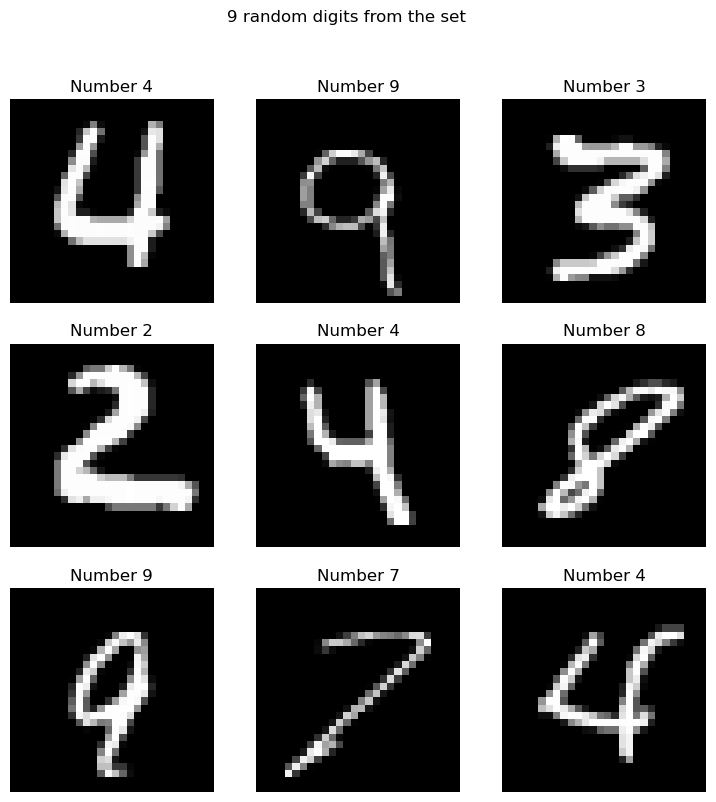

In [3]:
ix = [randint(0, train_X.shape[0] - 1) for _ in range(9)]
plt.figure( figsize=(9,9) )
plt.suptitle( "9 random digits from the set" )
for pos, i  in enumerate(ix):
    plt.subplot(3, 3, pos+1)
    plt.imshow(train_X[i], cmap="gray")
    plt.title(f"Number {train_y[i]}")
    plt.axis("off")
plt.show()

## Data preprocessing  
Data normalization, so it is easier for the model to perform calculations.  
Reshaping the data, so we have 2D data instead of 3D


In [4]:
train_X =  normalize(train_X)
test_X = normalize(test_X)

train_X = train_X.reshape( train_X.shape[0], train_X.shape[1] ** 2)
test_X = test_X.reshape( test_X.shape[0], test_X.shape[1] ** 2)

print('X_train (after flattening): ' + str(train_X.shape))
print('X_test (after flattening):  '  + str(test_X.shape))


X_train (after flattening): (60000, 784)
X_test (after flattening):  (10000, 784)


## Building and compiling the model

In [5]:

model = Sequential([
    Dense( 128, input_shape = (28*28, ), activation = "relu", name = "L1"),
    Dense( 64, activation = "sigmoid", name = "L2"),
    Dense( 10, activation = "softmax", name = "L3")
])

model.compile( optimizer = 'adam',
               loss = 'sparse_categorical_crossentropy',
               metrics = ['accuracy'] )

history = model.fit(train_X, train_y, epochs = 20, batch_size = 100)

Epoch 1/20
600/600 [==============================] - 3s 3ms/step - loss: 0.5753 - accuracy: 0.8520
Epoch 2/20
600/600 [==============================] - 2s 3ms/step - loss: 0.2147 - accuracy: 0.9384
Epoch 3/20
600/600 [==============================] - 2s 3ms/step - loss: 0.1511 - accuracy: 0.9556
Epoch 4/20
600/600 [==============================] - 2s 3ms/step - loss: 0.1152 - accuracy: 0.9666
Epoch 5/20
600/600 [==============================] - 2s 3ms/step - loss: 0.0920 - accuracy: 0.9737
Epoch 6/20
600/600 [==============================] - 2s 3ms/step - loss: 0.0751 - accuracy: 0.9782
Epoch 7/20
600/600 [==============================] - 2s 3ms/step - loss: 0.0620 - accuracy: 0.9820
Epoch 8/20
600/600 [==============================] - 2s 3ms/step - loss: 0.0523 - accuracy: 0.9849
Epoch 9/20
600/600 [==============================] - 3s 4ms/step - loss: 0.0438 - accuracy: 0.9877
Epoch 10/20
600/600 [==============================] - 2s 3ms/step - loss: 0.0370 - accuracy: 0.9901

## Model's architecture

In [6]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 L1 (Dense)                  (None, 128)               100480    
                                                                 
 L2 (Dense)                  (None, 64)                8256      
                                                                 
 L3 (Dense)                  (None, 10)                650       
                                                                 
Total params: 109386 (427.29 KB)
Trainable params: 109386 (427.29 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


## Accuracy aand loss analysis (on the training set)
Let's see how loss and accuracy have changed over time during the learning process

Text(0.5, 1.0, 'Loss history')

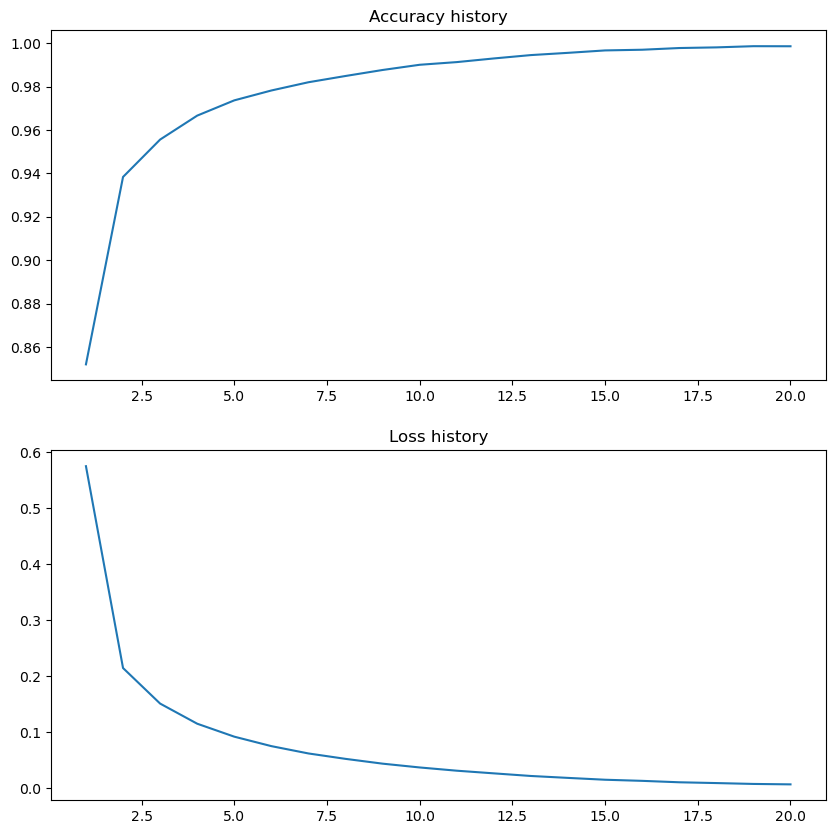

In [7]:
fig, axes = plt.subplots(2,1, figsize = (10,10))
axes = axes.flatten()
x_ax = range(1,21)

axes[0].plot(x_ax, history.history['accuracy'])
axes[0].set_title("Accuracy history")

axes[1].plot(x_ax, history.history['loss'])
axes[1].set_title("Loss history")


## Model evaluation
Checking how well the model handles the test data

In [8]:
pred_y = np.argmax(model.predict(test_X), axis=1)
loss, accuracy = model.evaluate(test_X, test_y)

print(f"Model's loss: {loss}")
print(f"Model's accuracy: {accuracy}")

313/313 [==============================] - 1s 1ms/step - loss: 0.0917 - accuracy: 0.9769
Model's loss: 0.09174712747335434
Model's accuracy: 0.9768999814987183


Let's take a look at misclasified objects

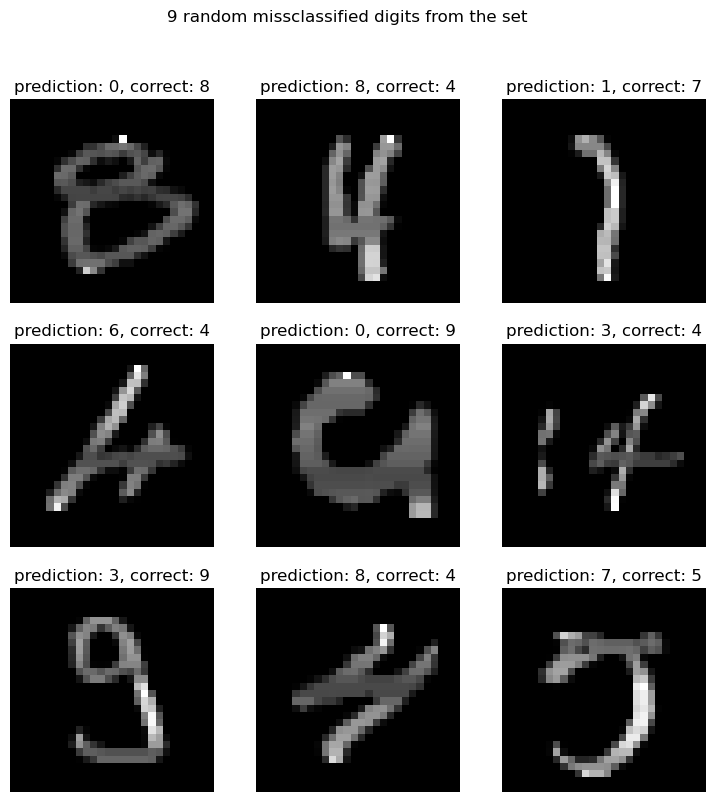

In [9]:
wrong_idx = np.where(pred_y != test_y)[0]

ix = [choice(wrong_idx) for _ in range(9)]
plt.figure( figsize=(9,9) )
plt.suptitle( "9 random missclassified digits from the set" )
for pos, i  in enumerate(ix):
    plt.subplot(3, 3, pos+1)
    plt.imshow(test_X[i].reshape(28,28), cmap="gray")
    plt.title(f"prediction: {pred_y[i]}, correct: {test_y[i]}")
    plt.axis("off")
plt.show()
